# Coupled Hydro-Thermal Dynamics: RiverFlowDynamics + RiverTemperatureDynamics

## Overview

One of the core design philosophies of Landlab is the ability to couple independent components to model complex, interacting Earth system processes.

In this tutorial, we will explicitly couple `RiverFlowDynamics` (to solve the shallow water equations for flow routing) with `RiverTemperatureDynamics` (to solve the advection-dispersion and atmospheric energy budget). 

While this example runs under steady flow conditions, this coupled architecture allows for future simulations of highly dynamic events, such as tracking how a sudden flash flood or diurnal snowmelt pulse affects river temperatures throughout the day.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from landlab import RasterModelGrid
from landlab.components import RiverFlowDynamics, RiverTemperatureDynamics

### 1. Generate Dynamic Meteorological Forcing
We create a synthetic 24-hour meteorological dataset and save it to a CSV for the thermal component to interpolate.

In [2]:
times = np.arange(0, 86400 + 3600, 3600)

T_air = 15.0 + 10.0 * np.sin(np.pi * (times - 8 * 3600) / (12 * 3600)) 
Q_sw = np.zeros_like(times)
daylight = (times >= 6 * 3600) & (times <= 18 * 3600)
Q_sw[daylight] = 800.0 * np.sin(np.pi * (times[daylight] - 6 * 3600) / (12 * 3600)) 
cloud_cover = np.linspace(0.0, 0.6, len(times))  

df_met = pd.DataFrame({
    "time_sec": times,
    "T_air": T_air,
    "RH": np.full_like(times, 40.0),
    "u_wind": np.full_like(times, 1.5),
    "Q_sw": Q_sw,
    "cloud_cover": cloud_cover
})

met_filename = "synthetic_diurnal_met.csv"
df_met.to_csv(met_filename, index=False)

### 2. Grid Setup and Hydrodynamic Spin-Up
We instantiate the `RiverFlowDynamics` component and run it for a brief period to allow the water surface to equilibrate and reach a steady state. We carefully balance Manning's equation to prevent numerical shockwaves at the inlet.

In [3]:
dx = 2.0
nrows = 13
ncols = 101
dt_step = 0.5  # Shared time step for both components

channel_slope = 0.002
h_normal = 0.4
mannings_n = 0.03
v_normal = (1.0 / mannings_n) * (h_normal ** (2.0 / 3.0)) * (channel_slope ** 0.5)

grid = RasterModelGrid((nrows, ncols), xy_spacing=dx)

# Topography
te = grid.add_field("topographic__elevation", (dx * (ncols - 1) - grid.x_of_node) * channel_slope, at="node", clobber=True)
bank_mask = (grid.y_of_node < dx) | (grid.y_of_node > dx * (nrows - 2))
channel_mask = ~bank_mask
te[bank_mask] = 5.0

# Hydrodynamic Initial Conditions
h = grid.add_zeros("surface_water__depth", at="node", clobber=True)
vel = grid.add_zeros("surface_water__velocity", at="link", clobber=True)
wse = grid.add_zeros("surface_water__elevation", at="node", clobber=True)

h[channel_mask] = h_normal
wse[:] = te + h

horiz_links = grid.horizontal_links
link_y = grid.y_of_node[grid.node_at_link_tail[horiz_links]]
channel_hlinks = horiz_links[(link_y >= dx) & (link_y <= dx * (nrows - 2))]
vel[channel_hlinks] = v_normal

# Boundary conditions for flow
channel_rows = np.arange(1, nrows - 1)
fixed_entry_nodes = channel_rows * ncols
fixed_entry_links = grid.links_at_node[fixed_entry_nodes][:, 0]

# Create Hydrodynamic Component
rfd = RiverFlowDynamics(
    grid,
    dt=dt_step,
    mannings_n=mannings_n,
    eddy_viscosity=1e-3,
    threshold_depth=0.005,
    theta=0.7,
    fixed_entry_nodes=fixed_entry_nodes,
    fixed_entry_links=fixed_entry_links,
    entry_nodes_h_values=np.full(len(fixed_entry_nodes), h_normal),
    entry_links_vel_values=np.full(len(fixed_entry_links), v_normal),
)

print("Spinning up hydrodynamics...")
for _ in range(200):
    rfd.run_one_step()
print(f"Steady state reached. Mean velocity: {vel[channel_hlinks].mean():.3f} m/s")

Spinning up hydrodynamics...
Steady state reached. Mean velocity: 0.809 m/s


### 3. Initialize Thermal Fields and Component
Now that the water is flowing smoothly, we set up the energy budget variables.

In [4]:
T_w = grid.add_zeros("surface_water__temperature", at="node", clobber=True)
T_w[:] = 12.0

T_bed = grid.add_zeros("sediment__temperature", at="node", clobber=True)
T_bed[:] = 14.0

T_gw = grid.add_zeros("groundwater__temperature", at="node", clobber=True)
T_gw[:] = 10.0

q_gw = grid.add_zeros("groundwater__specific_discharge", at="node", clobber=True)
q_gw[channel_mask] = 2.0e-5  

# Link the hydrodynamic velocity to the thermal advection field
adv_vel = grid.add_zeros("advection__velocity", at="link", clobber=True)
adv_vel[:] = vel[:]

grid.add_zeros("solar__altitude_angle", at="node", clobber=True)[:] = np.radians(50.0)

for field in ["air__temperature", "air__relative_humidity", "air__velocity", 
              "radiation__incoming_shortwave_flux", "cloud_cover__fraction"]:
    grid.add_zeros(field, at="node", clobber=True)

rtd = RiverTemperatureDynamics(
    grid,
    met_file=met_filename,  
    shade_factor=0.2,       
    k_bed=1.5,              
    dz_bed=0.5,             
)

### 4. The Fully Coupled 24-Hour Loop
Inside the time loop, we step both components forward. **Crucially**, after `RiverFlowDynamics` computes the new fluid velocities, we pass those updated velocities to the `advection__velocity` field so `RiverTemperatureDynamics` can use them.

*(Note: Because we are running a 2D hydrodynamic solver 172,800 times, this cell will take several minutes to execute.)*

In [5]:
n_steps = int(86400 / dt_step)
center_node = grid.core_nodes[len(grid.core_nodes) // 2]

history = {
    "time_hr": [], "T_water": [], "T_bed": [], "T_air": [],
    "Q_sw_net": [], "Q_lw_in": [], "Q_lw_out": [], 
    "Q_evap": [], "Q_conv": [], "Q_bed": [], "Q_gw": [], "Q_net": []
}

print(f"Running fully coupled 24-hour simulation ({n_steps} steps)...")
for step in range(n_steps):
    t_sim = step * dt_step
    
    # 1. Run Hydrodynamics
    rfd.run_one_step()
    
    # 2. Handshake: Pass updated velocity to the thermal advection field
    adv_vel[:] = vel[:]
    
    # 3. Run Thermodynamics
    rtd.run_one_step(dt_step, t_sim=t_sim)
    
    # 4. Apply Dynamic Thermal Boundary Conditions (upstream heating)
    current_air = grid.at_node["air__temperature"][center_node]
    upstream_T = 12.0 + 0.3 * (current_air - 15.0) 
    T_w[fixed_entry_nodes] = upstream_T
    T_w[bank_mask] = upstream_T
    
    # 5. Record Data
    if t_sim % 900 == 0:
        history["time_hr"].append(t_sim / 3600.0)
        history["T_water"].append(T_w[center_node])
        history["T_bed"].append(T_bed[center_node])
        history["T_air"].append(grid.at_node["air__temperature"][center_node])
        history["Q_sw_net"].append(rtd.Q_sw_net[center_node])
        history["Q_lw_in"].append(rtd.Q_lw_in[center_node])
        history["Q_lw_out"].append(rtd.Q_lw_out[center_node])
        history["Q_evap"].append(rtd.Q_evap[center_node])
        history["Q_conv"].append(rtd.Q_conv[center_node])
        history["Q_bed"].append(rtd.Q_bed[center_node])
        history["Q_gw"].append(rtd.Q_gw[center_node])
        history["Q_net"].append(rtd.Q_net[center_node])
        
    if t_sim > 0 and t_sim % 3600 == 0:
        print(f"  ... {t_sim / 3600.0:.0f} hours simulated")

print("Coupled simulation complete!")

Running fully coupled 24-hour simulation (172800 steps)...
  ... 6 hours simulated
  ... 12 hours simulated
  ... 18 hours simulated
Coupled simulation complete!


### 5. Visualizing the Results
We generate our split plots to view the wide air temperature swing alongside the tightly bounded water temperature curve.

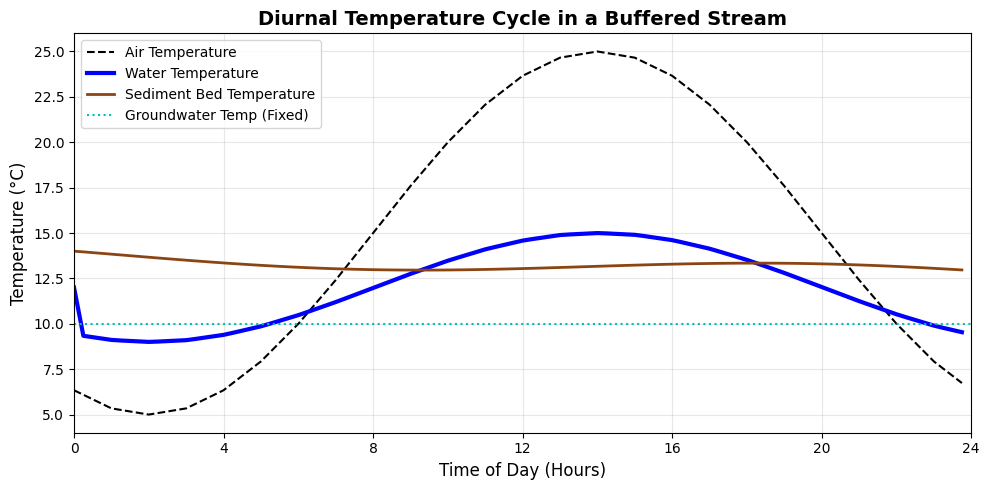

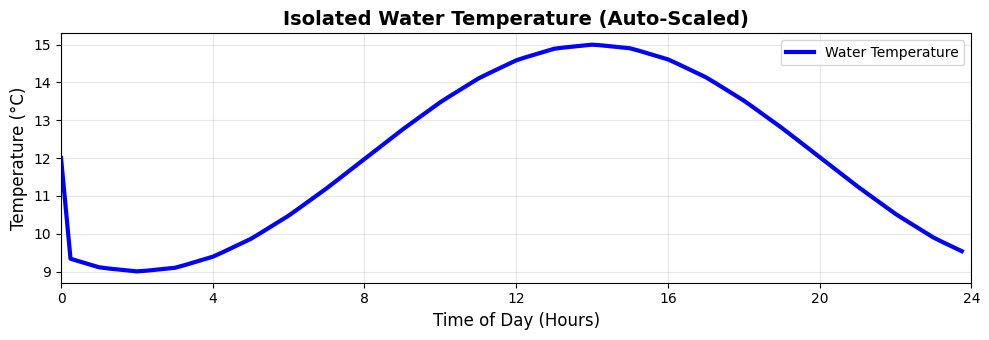

In [6]:
# Main Plot: Full System Overview
plt.figure(figsize=(10, 5))
plt.plot(history["time_hr"], history["T_air"], 'k--', label='Air Temperature')
plt.plot(history["time_hr"], history["T_water"], 'b-', lw=3, label='Water Temperature')
plt.plot(history["time_hr"], history["T_bed"], 'saddlebrown', lw=2, label='Sediment Bed Temperature')
plt.axhline(10.0, color='c', linestyle=':', label='Groundwater Temp (Fixed)')

plt.title("Diurnal Temperature Cycle in a Buffered Stream", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day (Hours)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 4))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Zoomed Plot: Isolated Water Temperature
plt.figure(figsize=(10, 3.5))
plt.plot(history["time_hr"], history["T_water"], 'b-', lw=3, label='Water Temperature')

plt.title("Isolated Water Temperature (Auto-Scaled)", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day (Hours)", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 4))

y_min, y_max = plt.ylim()
if (y_max - y_min) < 0.5:
    plt.ylim(y_min - 0.25, y_max + 0.25)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Finally, the energy budget.

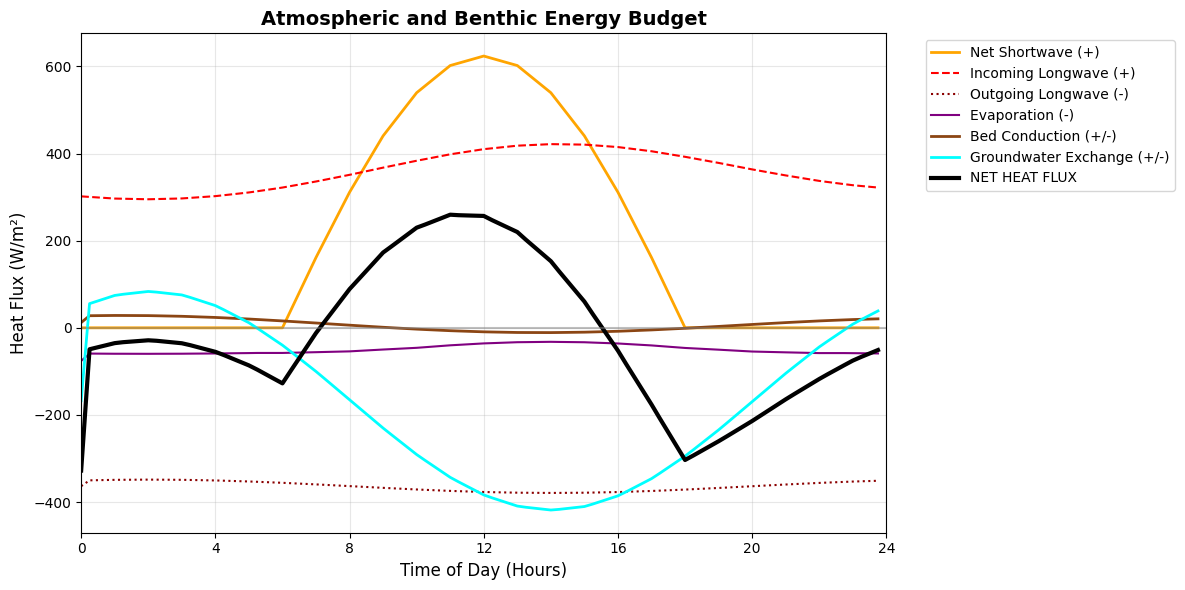

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(history["time_hr"], history["Q_sw_net"], color='orange', lw=2, label='Net Shortwave (+)')
plt.plot(history["time_hr"], history["Q_lw_in"], color='red', ls='--', label='Incoming Longwave (+)')
plt.plot(history["time_hr"], [-x for x in history["Q_lw_out"]], color='darkred', ls=':', label='Outgoing Longwave (-)')
plt.plot(history["time_hr"], [-x for x in history["Q_evap"]], color='purple', label='Evaporation (-)')
plt.plot(history["time_hr"], history["Q_bed"], color='saddlebrown', lw=2, label='Bed Conduction (+/-)')
plt.plot(history["time_hr"], history["Q_gw"], color='cyan', lw=2, label='Groundwater Exchange (+/-)')
plt.plot(history["time_hr"], history["Q_net"], color='black', lw=3, label='NET HEAT FLUX')

plt.axhline(0, color='gray', alpha=0.5)
plt.title("Atmospheric and Benthic Energy Budget", fontsize=14, fontweight="bold")
plt.xlabel("Time of Day (Hours)", fontsize=12)
plt.ylabel("Heat Flux (W/m²)", fontsize=12)
plt.xlim(0, 24)
plt.xticks(np.arange(0, 25, 4))
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()